# 21 — FNSPID sentiment-augmented volatility targeting

**Question.** Does aggregate negative-news pressure improve a conventional
HAR-style forecast of near-term SPY variance, and does that incremental risk
forecast produce a useful low-turnover exposure rule?

This is not another directional sentiment strategy. It tests the repeated
empirical clue from the earlier work: semantics appear more informative about
risk magnitude than signed returns.

## Frozen design (written before this candidate's evaluation execution)

- **Spine:** FNSPID only; no pooling with LSEG.
- **Decision time:** adjusted open on `session_date`. Date-only FNSPID news was
  already mapped conservatively to the next XNYS session, so current pressure
  is known at the decision open.
- **Outcome:** mean squared SPY adjusted-open return over the next five
  sessions. Overlap is handled with 20-session circular-block inference.
- **Control forecast:** log HAR variance using the return ending at the
  decision open plus trailing 5- and 22-session mean squared returns.
- **Sentiment forecast:** the identical control plus one feature,
  `clip(max(negative_pressure_z, 0), 0, 3)`. The pressure z-score uses the
  preceding 252 news sessions (minimum 126); the current day never enters its
  own baseline.
- **Fit:** OLS and a positive QLIKE scale fitted only to targets ending by
  2019-12-31. If the development sentiment coefficient is not positive, the
  deployable sentiment forecast collapses to the control rather than taking
  the opposite risk bet.
- **Portfolio:** target 10% annual volatility, clip exposure to 25%–100%, no
  leverage or shorting, cash return zero. Both models use the same rule.
- **Costs:** 2 bps per side primary; fixed 0/1/2/5/10-bps sensitivity; entry,
  transitions, and final liquidation all charged.
- **Primary forecasting estimand:** evaluation mean
  `QLIKE(control) - QLIKE(sentiment)`; positive favours sentiment.
- **Primary strategy estimand:** paired evaluation net-return difference,
  sentiment target minus control target.
- **Useful-risk gate:** positive development coefficient; QLIKE improvement
  with a positive 95% block-bootstrap lower bound; net Sharpe improvement of
  at least 0.10; maximum-drawdown improvement of at least 10% of the control
  loss; paired net-return lower bound above -1 bp/day; and non-negative mean
  net difference in both 2020 and 2021–2023.
- **Alpha gate:** paired net-return lower bound above zero and net Sharpe
  improvement of at least 0.10. This is secondary to the risk gate.

The 2020–2023 block has already influenced earlier dissertation work, so this
remains an exploratory chronological evaluation—not pristine confirmation.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from experiments.lib.risk_overlay import (  # noqa: E402
    reprice_daily,
    summarize_weight_backtest,
)
from experiments.lib.volatility_target import (  # noqa: E402
    CONTROL_FEATURES,
    SENTIMENT_FEATURE,
    VolatilityTargetConfig,
    backtest_single_asset_exposure,
    build_volatility_frame,
    build_volatility_target_exposure,
    fit_log_variance_model,
    model_table,
    paired_circular_block_mean,
    predict_variance,
    qlike_loss,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260805
FROZEN_DEV_END = pd.Timestamp("2019-12-31")
FROZEN_EVAL_START = pd.Timestamp("2020-01-01")
CONFIG = VolatilityTargetConfig(random_seed=SEED)
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)

OUTPUT_DIR = REPO_ROOT / "experiments" / "generated" / "21_fnspid_sentiment_volatility_target"
PRESSURE_PATH = (
    REPO_ROOT
    / "experiments"
    / "generated"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "daily_aggregate_pressure.parquet"
)
DEV_RETURN_PATH = (
    REPO_ROOT
    / "experiments"
    / "generated"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "development_baseline_daily.parquet"
)
EVAL_RETURN_PATH = (
    REPO_ROOT
    / "experiments"
    / "generated"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "evaluation_baseline_daily.parquet"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")
print(f"seed:   {SEED}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/experiments/generated/21_fnspid_sentiment_volatility_target
seed:   20260805


## Load the aggregate signal and independent SPY returns

Notebook 20's baseline daily files contain SPY open-to-open **gross** returns.
Its transaction costs are ignored here; every Notebook 21 arm is re-costed
from its own exposure path.

In [2]:
for required_path in (PRESSURE_PATH, DEV_RETURN_PATH, EVAL_RETURN_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Run Notebook 20 first; missing {required_path}")

pressure = pd.read_parquet(PRESSURE_PATH)
returns = pd.concat(
    [
        pd.read_parquet(DEV_RETURN_PATH)[["session_date", "gross_return"]],
        pd.read_parquet(EVAL_RETURN_PATH)[["session_date", "gross_return"]],
    ],
    ignore_index=True,
).sort_values("session_date", kind="mergesort")
returns["session_date"] = pd.to_datetime(returns["session_date"]).dt.normalize()
pressure["session_date"] = pd.to_datetime(pressure["session_date"]).dt.normalize()

if returns["session_date"].duplicated().any():
    raise RuntimeError("SPY return inputs overlap by session")
if not returns["session_date"].is_monotonic_increasing:
    raise RuntimeError("SPY returns are not chronological")

input_audit = pd.DataFrame(
    [
        {
            "input": "SPY adjusted-open returns",
            "rows": len(returns),
            "start": returns["session_date"].min(),
            "end": returns["session_date"].max(),
            "missing": int(returns["gross_return"].isna().sum()),
        },
        {
            "input": "aggregate negative pressure",
            "rows": len(pressure),
            "start": pressure["session_date"].min(),
            "end": pressure["session_date"].max(),
            "missing": int(pressure["negative_pressure_z"].isna().sum()),
        },
    ]
)
display(input_audit)

,input,rows,start,end,missing
0,SPY adjusted-open returns,3261,2011-01-03,2023-12-18,0
1,aggregate negative pressure,3262,2011-01-03,2023-12-18,126


## Build causal HAR features and lock the fit rows

Training targets—not merely decision dates—must end inside development. This
prevents the overlapping five-session outcome at the boundary from reaching
into evaluation.

In [3]:
frame = build_volatility_frame(returns, pressure, config=CONFIG)
train_mask = (
    frame["target_end_date"].notna()
    & frame["target_end_date"].le(FROZEN_DEV_END)
    & frame[SENTIMENT_FEATURE].notna()
)
evaluation_decision_mask = frame["session_date"].ge(FROZEN_EVAL_START)
evaluation_forecast_mask = evaluation_decision_mask & frame["target_end_date"].notna()

fit_audit = pd.DataFrame(
    [
        {
            "fit_rows_before_complete_case": int(train_mask.sum()),
            "first_fit_decision": frame.loc[train_mask, "session_date"].min(),
            "last_fit_decision": frame.loc[train_mask, "session_date"].max(),
            "last_fit_target_end": frame.loc[train_mask, "target_end_date"].max(),
            "first_evaluation_decision": frame.loc[evaluation_decision_mask, "session_date"].min(),
            "evaluation_decisions": int(evaluation_decision_mask.sum()),
            "evaluation_complete_targets": int(evaluation_forecast_mask.sum()),
        }
    ]
)
assert fit_audit.loc[0, "last_fit_target_end"] <= FROZEN_DEV_END
assert fit_audit.loc[0, "first_evaluation_decision"] >= FROZEN_EVAL_START
display(fit_audit)

,fit_rows_before_complete_case,first_fit_decision,last_fit_decision,last_fit_target_end,first_evaluation_decision,evaluation_decisions,evaluation_complete_targets
0,2133,2011-07-05,2019-12-23,2019-12-30,2020-01-02,998,994


## Fit once on development; do not select on evaluation

In [4]:
models = {
    "control_har": fit_log_variance_model(frame, CONTROL_FEATURES, train_mask),
    "sentiment_har": fit_log_variance_model(
        frame,
        [*CONTROL_FEATURES, SENTIMENT_FEATURE],
        train_mask,
    ),
}
coefficients = model_table(models)
sentiment_coefficient = models["sentiment_har"].coefficient_map()[SENTIMENT_FEATURE]
development_sign_gate = bool(sentiment_coefficient > 0)

control_forecast = predict_variance(frame, models["control_har"])
unrestricted_sentiment_forecast = predict_variance(frame, models["sentiment_har"])
sentiment_forecast = (
    unrestricted_sentiment_forecast.copy()
    if development_sign_gate
    else control_forecast.copy()
)

print(f"Development sentiment coefficient: {sentiment_coefficient:+.6f}")
print(f"Positive-sign deployment gate: {development_sign_gate}")
display(coefficients)

Development sentiment coefficient: +0.230225
Positive-sign deployment gate: True


,arm,n_train,intercept,qlike_scale,log_var_daily,log_var_weekly,log_var_monthly,positive_negative_pressure_z
0,control_har,2133,-2.866748,1.658899,0.026931,0.265835,0.434513,NaN
1,sentiment_har,2133,-3.251473,1.652228,0.022385,0.259956,0.416256,0.230225


## Primary forecast comparison: evaluation QLIKE

The comparison is paired on identical complete evaluation targets. Positive
loss differences favour the sentiment model.

In [5]:
forecast_eval = frame.loc[
    evaluation_forecast_mask,
    ["session_date", "target_end_date", "realized_variance_forward", SENTIMENT_FEATURE],
].copy()
forecast_eval["control_forecast"] = control_forecast.loc[forecast_eval.index]
forecast_eval["sentiment_forecast"] = sentiment_forecast.loc[forecast_eval.index]
forecast_eval = forecast_eval.dropna(subset=["control_forecast", "sentiment_forecast"])
forecast_eval["qlike_control"] = qlike_loss(
    forecast_eval["realized_variance_forward"].to_numpy(),
    forecast_eval["control_forecast"].to_numpy(),
)
forecast_eval["qlike_sentiment"] = qlike_loss(
    forecast_eval["realized_variance_forward"].to_numpy(),
    forecast_eval["sentiment_forecast"].to_numpy(),
)
forecast_eval["qlike_improvement"] = (
    forecast_eval["qlike_control"] - forecast_eval["qlike_sentiment"]
)
forecast_eval["log_mse_control"] = (
    np.log(forecast_eval["realized_variance_forward"] + CONFIG.variance_floor)
    - np.log(forecast_eval["control_forecast"])
) ** 2
forecast_eval["log_mse_sentiment"] = (
    np.log(forecast_eval["realized_variance_forward"] + CONFIG.variance_floor)
    - np.log(forecast_eval["sentiment_forecast"])
) ** 2

forecast_inference = pd.DataFrame(
    [
        {
            "estimand": "QLIKE control minus sentiment",
            **paired_circular_block_mean(
                forecast_eval["qlike_improvement"],
                block_length=CONFIG.bootstrap_block_length,
                replications=CONFIG.bootstrap_replications,
                seed=CONFIG.random_seed,
            ),
        },
        {
            "estimand": "log-MSE control minus sentiment",
            **paired_circular_block_mean(
                forecast_eval["log_mse_control"] - forecast_eval["log_mse_sentiment"],
                block_length=CONFIG.bootstrap_block_length,
                replications=CONFIG.bootstrap_replications,
                seed=CONFIG.random_seed + 1,
            ),
        },
    ]
)
forecast_metrics = pd.DataFrame(
    [
        {
            "arm": arm,
            "n_targets": len(forecast_eval),
            "mean_qlike": float(forecast_eval[f"qlike_{suffix}"].mean()),
            "log_variance_rmse": float(
                np.sqrt(forecast_eval[f"log_mse_{suffix}"].mean())
            ),
            "forecast_actual_spearman": float(
                forecast_eval[[f"{suffix}_forecast", "realized_variance_forward"]]
                .corr(method="spearman")
                .iloc[0, 1]
            ),
        }
        for arm, suffix in (("control_har", "control"), ("sentiment_har", "sentiment"))
    ]
)
display(forecast_metrics)
display(forecast_inference)

,arm,n_targets,mean_qlike,log_variance_rmse,forecast_actual_spearman
0,control_har,994,-7.884354,0.952400,0.614828
1,sentiment_har,994,-7.888620,0.936241,0.614343


,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,QLIKE control minus sentiment,994,0.004266,-0.015215,0.026676,0.685200,20,4999,20260805
1,log-MSE control minus sentiment,994,0.030519,0.000883,0.061697,0.050400,20,4999,20260806


## Translate both forecasts through the identical volatility target

In [6]:
decision = frame.loc[evaluation_decision_mask].copy()
control_exposure = build_volatility_target_exposure(
    decision,
    control_forecast.loc[decision.index],
    config=CONFIG,
    arm="control_har_target",
)
sentiment_exposure = build_volatility_target_exposure(
    decision,
    sentiment_forecast.loc[decision.index],
    config=CONFIG,
    arm="sentiment_har_target",
)
long_exposure = pd.DataFrame(
    {
        "session_date": decision["session_date"].to_numpy(),
        "arm": "long_spy",
        "forecast_variance": np.nan,
        "forecast_annual_volatility": np.nan,
        "exposure": 1.0,
    }
)

exposures = {
    "long_spy": long_exposure,
    "control_har_target": control_exposure,
    "sentiment_har_target": sentiment_exposure,
}
daily_paths = {
    arm: backtest_single_asset_exposure(
        decision[["session_date", "forward_return"]],
        exposure,
        cost_bps_per_side=CONFIG.cost_bps_per_side,
    )
    for arm, exposure in exposures.items()
}

common_dates = set.intersection(
    *(set(path["session_date"]) for path in daily_paths.values())
)
for arm in daily_paths:
    daily_paths[arm] = daily_paths[arm].loc[
        daily_paths[arm]["session_date"].isin(common_dates)
    ].reset_index(drop=True)

results = pd.DataFrame(
    [
        {"arm": arm, **summarize_weight_backtest(path, config=CONFIG)}
        for arm, path in daily_paths.items()
    ]
)
display(
    results[
        [
            "arm",
            "n_sessions",
            "mean_gross_exposure",
            "annualized_turnover",
            "sharpe_gross",
            "sharpe_net",
            "ann_vol_net",
            "total_return_net",
            "max_drawdown",
        ]
    ]
)

,arm,n_sessions,mean_gross_exposure,annualized_turnover,sharpe_gross,sharpe_net,ann_vol_net,total_return_net,max_drawdown
0,long_spy,998,1.000000,0.252505,0.568328,0.567850,0.213043,0.474961,-0.320490
1,control_har_target,998,0.618573,5.615735,0.693755,0.672674,0.106498,0.298474,-0.157300
2,sentiment_har_target,998,0.629580,7.046797,0.699363,0.673265,0.108106,0.303487,-0.165691


## Paired strategy inference, exposure attribution, and stability

In [7]:
control_daily = daily_paths["control_har_target"]
sentiment_daily = daily_paths["sentiment_har_target"]
paired_daily = control_daily[["session_date", "net_return"]].rename(
    columns={"net_return": "control_net"}
).merge(
    sentiment_daily[["session_date", "net_return"]].rename(
        columns={"net_return": "sentiment_net"}
    ),
    on="session_date",
    validate="1:1",
)
paired_daily["net_difference"] = paired_daily["sentiment_net"] - paired_daily["control_net"]
paired_daily["downside_sq_improvement"] = (
    np.minimum(paired_daily["control_net"], 0.0) ** 2
    - np.minimum(paired_daily["sentiment_net"], 0.0) ** 2
)

strategy_inference = pd.DataFrame(
    [
        {
            "estimand": "sentiment minus control net return",
            **paired_circular_block_mean(
                paired_daily["net_difference"],
                block_length=CONFIG.bootstrap_block_length,
                replications=CONFIG.bootstrap_replications,
                seed=CONFIG.random_seed + 2,
            ),
        },
        {
            "estimand": "control minus sentiment downside squared return",
            **paired_circular_block_mean(
                paired_daily["downside_sq_improvement"],
                block_length=CONFIG.bootstrap_block_length,
                replications=CONFIG.bootstrap_replications,
                seed=CONFIG.random_seed + 3,
            ),
        },
    ]
)

mean_sentiment_exposure = float(sentiment_daily["exposure"].mean())
constant_exposure = pd.DataFrame(
    {
        "session_date": decision["session_date"].to_numpy(),
        "arm": "constant_matched_exposure",
        "exposure": mean_sentiment_exposure,
    }
)
constant_daily = backtest_single_asset_exposure(
    decision[["session_date", "forward_return"]],
    constant_exposure,
    cost_bps_per_side=CONFIG.cost_bps_per_side,
)
constant_daily = constant_daily.loc[constant_daily["session_date"].isin(common_dates)].reset_index(drop=True)
constant_summary = summarize_weight_backtest(constant_daily, config=CONFIG)
timing_pair = sentiment_daily[["session_date", "net_return"]].rename(
    columns={"net_return": "sentiment_net"}
).merge(
    constant_daily[["session_date", "net_return"]].rename(
        columns={"net_return": "constant_net"}
    ),
    on="session_date",
    validate="1:1",
)
matched_exposure_attribution = pd.DataFrame(
    [
        {
            "sentiment_mean_exposure": mean_sentiment_exposure,
            "sentiment_net_sharpe": float(
                results.set_index("arm").loc["sentiment_har_target", "sharpe_net"]
            ),
            "constant_net_sharpe": constant_summary["sharpe_net"],
            **{
                f"timing_{key}": value
                for key, value in paired_circular_block_mean(
                    timing_pair["sentiment_net"] - timing_pair["constant_net"],
                    block_length=CONFIG.bootstrap_block_length,
                    replications=CONFIG.bootstrap_replications,
                    seed=CONFIG.random_seed + 4,
                ).items()
            },
        }
    ]
)

def annualized_sharpe(values: pd.Series) -> float:
    volatility = float(values.std(ddof=1))
    return (
        float(np.sqrt(252) * values.mean() / volatility)
        if volatility > 0 and math.isfinite(volatility)
        else float("nan")
    )


temporal_rows = []
for period, start, end in (
    ("2020", pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")),
    ("2021_2023", pd.Timestamp("2021-01-01"), pd.Timestamp("2023-12-31")),
):
    row = paired_daily.loc[paired_daily["session_date"].between(start, end)]
    temporal_rows.append(
        {
            "period": period,
            "n_sessions": len(row),
            "control_sharpe": annualized_sharpe(row["control_net"]),
            "sentiment_sharpe": annualized_sharpe(row["sentiment_net"]),
            "sentiment_minus_control_bps_day": float(row["net_difference"].mean() * 10_000),
            "control_total_return": float((1 + row["control_net"]).prod() - 1),
            "sentiment_total_return": float((1 + row["sentiment_net"]).prod() - 1),
        }
    )
temporal_stability = pd.DataFrame(temporal_rows)
display(strategy_inference)
display(matched_exposure_attribution)
display(temporal_stability)

,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,sentiment minus control net return,998,0.000005,-0.000028,0.000037,0.793400,20,4999,20260807
1,control minus sentiment downside squared return,998,-0.000001,-0.000001,0.000000,0.081000,20,4999,20260808


,sentiment_mean_exposure,sentiment_net_sharpe,constant_net_sharpe,timing_n,timing_mean,timing_ci_low,timing_ci_high,timing_p_two_sided,timing_block_length,timing_replications,timing_seed
0,0.629580,0.673265,0.567850,998,-0.000013,-0.000212,0.000194,0.898200,20,4999,20260809


,period,n_sessions,control_sharpe,sentiment_sharpe,sentiment_minus_control_bps_day,control_total_return,sentiment_total_return
0,2020,253,0.597468,0.669626,0.409480,0.066817,0.077598
1,2021_2023,745,0.704857,0.677083,-0.078154,0.217148,0.209623


## Cost sensitivity and predeclared gates

In [8]:
cost_rows = []
for cost_bps in COST_GRID:
    for arm in ("control_har_target", "sentiment_har_target"):
        repriced = reprice_daily(daily_paths[arm], cost_bps_per_side=cost_bps)
        summary = summarize_weight_backtest(repriced, config=CONFIG)
        cost_rows.append(
            {
                "cost_bps_per_side": cost_bps,
                "arm": arm,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)

result_index = results.set_index("arm")
control_result = result_index.loc["control_har_target"]
sentiment_result = result_index.loc["sentiment_har_target"]
qlike_test = forecast_inference.set_index("estimand").loc[
    "QLIKE control minus sentiment"
]
return_test = strategy_inference.set_index("estimand").loc[
    "sentiment minus control net return"
]
sharpe_improvement = float(sentiment_result["sharpe_net"] - control_result["sharpe_net"])
drawdown_relative_improvement = float(
    (abs(control_result["max_drawdown"]) - abs(sentiment_result["max_drawdown"]))
    / abs(control_result["max_drawdown"])
)
stable_both_periods = bool(
    temporal_stability["sentiment_minus_control_bps_day"].ge(0).all()
)
forecast_gate = bool(development_sign_gate and qlike_test["ci_low"] > 0)
alpha_gate = bool(return_test["ci_low"] > 0 and sharpe_improvement >= 0.10)
useful_risk_gate = bool(
    forecast_gate
    and sharpe_improvement >= 0.10
    and drawdown_relative_improvement >= 0.10
    and return_test["ci_low"] > -0.0001
    and stable_both_periods
)

gates = pd.DataFrame(
    [
        {
            "development_sentiment_coefficient_positive": development_sign_gate,
            "qlike_improvement": qlike_test["mean"],
            "qlike_ci_low": qlike_test["ci_low"],
            "forecast_gate": forecast_gate,
            "net_sharpe_improvement": sharpe_improvement,
            "drawdown_relative_improvement": drawdown_relative_improvement,
            "paired_net_ci_low_bps_day": return_test["ci_low"] * 10_000,
            "stable_nonnegative_mean_both_periods": stable_both_periods,
            "alpha_gate": alpha_gate,
            "useful_risk_gate": useful_risk_gate,
        }
    ]
)
display(cost_curve)
display(gates)

,cost_bps_per_side,arm,sharpe_net,total_return_net,max_drawdown
0,0.000000,control_har_target,0.693755,0.310073,-0.155871
1,0.000000,sentiment_har_target,0.699363,0.318118,-0.163709
2,1.000000,control_har_target,0.683215,0.304261,-0.156586
3,1.000000,sentiment_har_target,0.686314,0.310782,-0.164701
4,2.000000,control_har_target,0.672674,0.298474,-0.157300
5,2.000000,sentiment_har_target,0.673265,0.303487,-0.165691
6,5.000000,control_har_target,0.641048,0.281268,-0.159438
7,5.000000,sentiment_har_target,0.634116,0.281844,-0.168654
8,10.000000,control_har_target,0.588326,0.253093,-0.162991
9,10.000000,sentiment_har_target,0.568868,0.246566,-0.173570


,development_sentiment_coefficient_positive,qlike_improvement,qlike_ci_low,forecast_gate,net_sharpe_improvement,drawdown_relative_improvement,paired_net_ci_low_bps_day,stable_nonnegative_mean_both_periods,alpha_gate,useful_risk_gate
0,True,0.004266,-0.015215,False,0.000590,-0.053342,-0.281826,False,False,False


## Figures

findfont: Failed to find font weight medium, now using 400.


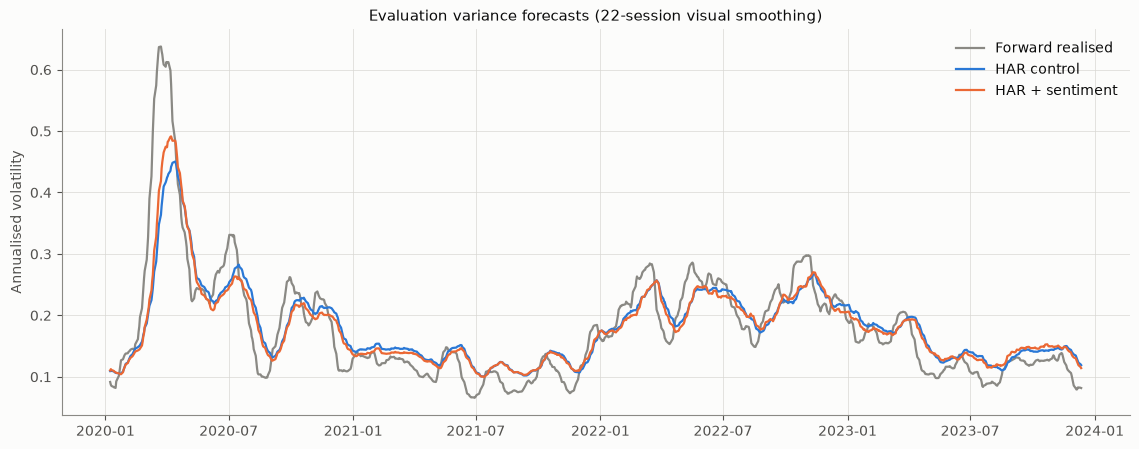

In [9]:
plot_forecast = forecast_eval.copy()
plot_forecast["realized_annual_vol"] = np.sqrt(
    plot_forecast["realized_variance_forward"] * 252
)
plot_forecast["control_annual_vol"] = np.sqrt(plot_forecast["control_forecast"] * 252)
plot_forecast["sentiment_annual_vol"] = np.sqrt(plot_forecast["sentiment_forecast"] * 252)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
for column, label, colour in (
    ("realized_annual_vol", "Forward realised", INK["muted"]),
    ("control_annual_vol", "HAR control", CATEGORICAL[0]),
    ("sentiment_annual_vol", "HAR + sentiment", CATEGORICAL[1]),
):
    smoothed = plot_forecast.set_index("session_date")[column].rolling(22, min_periods=5).mean()
    ax.plot(smoothed.index, smoothed, label=label, color=colour, linewidth=1.6)
ax.set_ylabel("Annualised volatility")
ax.set_title("Evaluation variance forecasts (22-session visual smoothing)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_volatility_forecasts.png", dpi=170, bbox_inches="tight")
plt.show()

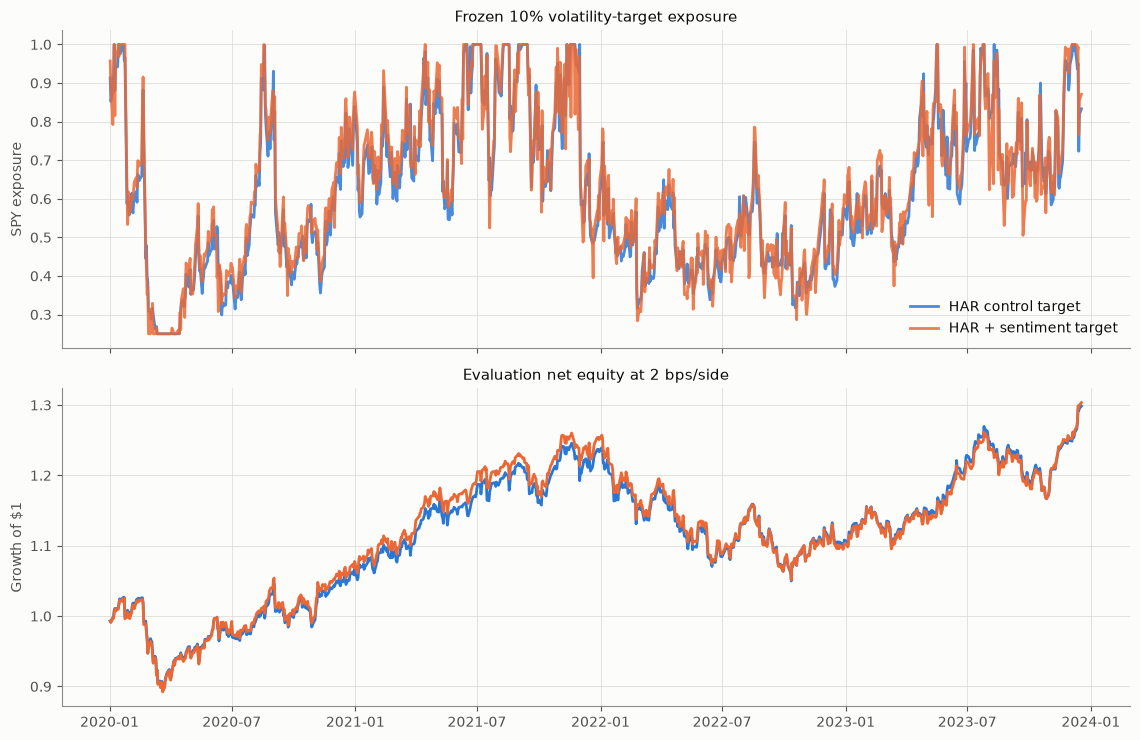

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)
for arm, label, colour in (
    ("control_har_target", "HAR control target", CATEGORICAL[0]),
    ("sentiment_har_target", "HAR + sentiment target", CATEGORICAL[1]),
):
    path = daily_paths[arm]
    axes[0].plot(path["session_date"], path["exposure"], label=label, color=colour, alpha=0.85)
    axes[1].plot(
        path["session_date"],
        (1 + path["net_return"]).cumprod(),
        label=label,
        color=colour,
    )
axes[0].set_ylabel("SPY exposure")
axes[0].set_title("Frozen 10% volatility-target exposure")
axes[0].legend(loc="lower right")
axes[1].set_ylabel("Growth of $1")
axes[1].set_title("Evaluation net equity at 2 bps/side")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_equity.png", dpi=170, bbox_inches="tight")
plt.show()

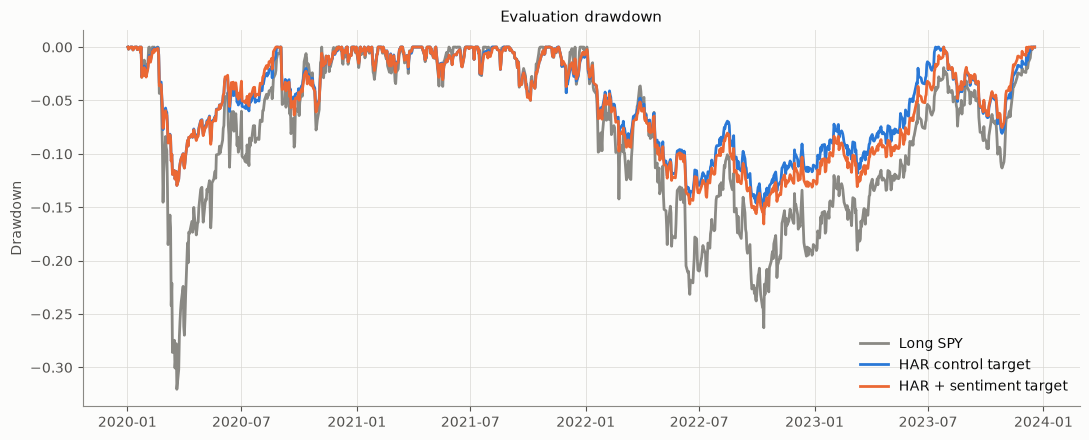

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for arm, label, colour in (
    ("long_spy", "Long SPY", INK["muted"]),
    ("control_har_target", "HAR control target", CATEGORICAL[0]),
    ("sentiment_har_target", "HAR + sentiment target", CATEGORICAL[1]),
):
    path = daily_paths[arm]
    equity = (1 + path["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1
    ax.plot(path["session_date"], drawdown, label=label, color=colour)
ax.set_ylabel("Drawdown")
ax.set_title("Evaluation drawdown")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

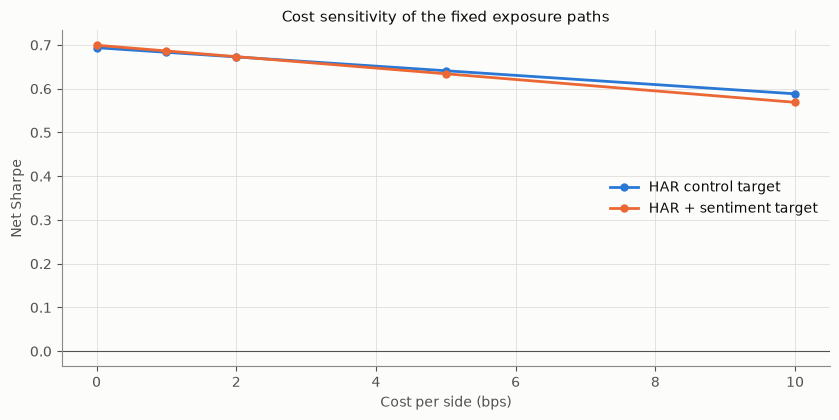

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for arm, label, colour in (
    ("control_har_target", "HAR control target", CATEGORICAL[0]),
    ("sentiment_har_target", "HAR + sentiment target", CATEGORICAL[1]),
):
    part = cost_curve.loc[cost_curve["arm"].eq(arm)]
    ax.plot(part["cost_bps_per_side"], part["sharpe_net"], marker="o", label=label, color=colour)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Cost per side (bps)")
ax.set_ylabel("Net Sharpe")
ax.set_title("Cost sensitivity of the fixed exposure paths")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

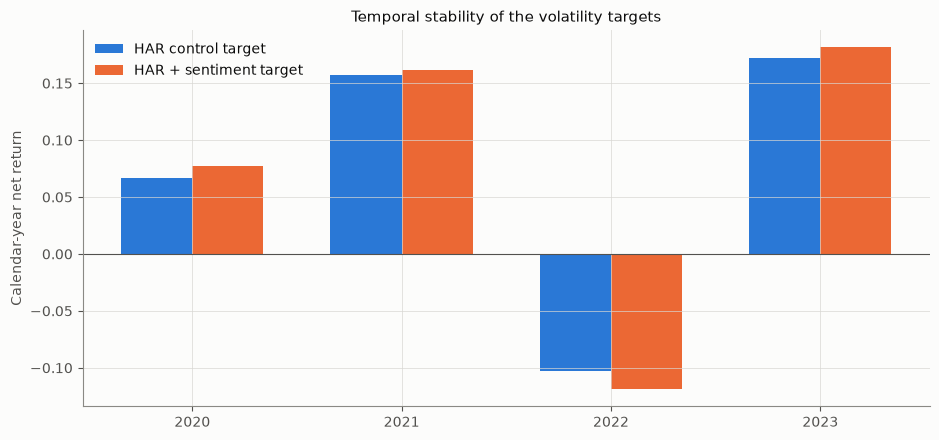

In [13]:
yearly_rows = []
for arm, path in daily_paths.items():
    for year, group in path.groupby(path["session_date"].dt.year):
        yearly_rows.append(
            {
                "arm": arm,
                "year": int(year),
                "net_return": float((1 + group["net_return"]).prod() - 1),
                "net_sharpe": annualized_sharpe(group["net_return"]),
            }
        )
yearly = pd.DataFrame(yearly_rows)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
years = sorted(yearly["year"].unique())
x = np.arange(len(years))
width = 0.34
for offset, (arm, label, colour) in enumerate(
    (
        ("control_har_target", "HAR control target", CATEGORICAL[0]),
        ("sentiment_har_target", "HAR + sentiment target", CATEGORICAL[1]),
    )
):
    values = yearly.loc[yearly["arm"].eq(arm)].set_index("year").reindex(years)["net_return"]
    ax.bar(x + (offset - 0.5) * width, values, width, label=label, color=colour)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xticks(x, years)
ax.set_ylabel("Calendar-year net return")
ax.set_title("Temporal stability of the volatility targets")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "yearly_returns.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [14]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
fit_audit.to_csv(OUTPUT_DIR / "fit_audit.csv", index=False)
coefficients.to_csv(OUTPUT_DIR / "model_coefficients.csv", index=False)
forecast_metrics.to_csv(OUTPUT_DIR / "forecast_metrics.csv", index=False)
forecast_inference.to_csv(OUTPUT_DIR / "forecast_inference.csv", index=False)
results.to_csv(OUTPUT_DIR / "strategy_results.csv", index=False)
strategy_inference.to_csv(OUTPUT_DIR / "strategy_inference.csv", index=False)
matched_exposure_attribution.to_csv(OUTPUT_DIR / "matched_exposure_attribution.csv", index=False)
temporal_stability.to_csv(OUTPUT_DIR / "temporal_stability.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
yearly.to_csv(OUTPUT_DIR / "yearly_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
forecast_eval.to_parquet(OUTPUT_DIR / "evaluation_forecasts.parquet", index=False)
for arm, path in daily_paths.items():
    path.to_parquet(OUTPUT_DIR / f"evaluation_{arm}_daily.parquet", index=False)
constant_daily.to_parquet(OUTPUT_DIR / "evaluation_constant_matched_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

if useful_risk_gate:
    verdict = "The sentiment forecast passes the predeclared useful-risk gate."
elif alpha_gate:
    verdict = "The sentiment target passes the secondary alpha gate but not the useful-risk gate."
else:
    verdict = "The sentiment-augmented volatility target does not pass either predeclared gate."

manifest = {
    "notebook": "21_fnspid_sentiment_volatility_target",
    "built_for": "incremental aggregate-sentiment variance forecasting and SPY volatility targeting",
    "analysis_status": "exploratory_frozen_before_notebook21_evaluation_execution_2026-08-05",
    "git_commit_at_execution": git_commit,
    "spine": "FNSPID_aggregate_only",
    "split": {
        "development_target_end_max": str(FROZEN_DEV_END.date()),
        "evaluation_decision_start": str(FROZEN_EVAL_START.date()),
        "evaluation_previously_opened_elsewhere": True,
    },
    "design": {
        "forecast_horizon_sessions": CONFIG.forecast_horizon,
        "control_features": list(CONTROL_FEATURES),
        "sentiment_feature": f"clip(max(negative_pressure_z, 0), 0, {CONFIG.sentiment_clip:g})",
        "sentiment_sign_gate": "positive development coefficient; otherwise deploy control",
        "target_annual_volatility": CONFIG.target_annual_volatility,
        "exposure_bounds": [CONFIG.minimum_exposure, CONFIG.maximum_exposure],
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "cost_grid": list(COST_GRID),
        "cash_return": 0.0,
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": CONFIG.bootstrap_block_length,
            "replications": CONFIG.bootstrap_replications,
            "seed": CONFIG.random_seed,
        },
    },
    "input_sha256": {
        str(PRESSURE_PATH.relative_to(REPO_ROOT)): sha256(PRESSURE_PATH),
        str(DEV_RETURN_PATH.relative_to(REPO_ROOT)): sha256(DEV_RETURN_PATH),
        str(EVAL_RETURN_PATH.relative_to(REPO_ROOT)): sha256(EVAL_RETURN_PATH),
    },
    "development_sentiment_coefficient": sentiment_coefficient,
    "development_sign_gate": development_sign_gate,
    "forecast_metrics": json.loads(forecast_metrics.to_json(orient="records")),
    "forecast_inference": json.loads(forecast_inference.to_json(orient="records")),
    "strategy_results": json.loads(results.to_json(orient="records")),
    "strategy_inference": json.loads(strategy_inference.to_json(orient="records")),
    "temporal_stability": json.loads(temporal_stability.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "verdict": verdict,
    "limitations": [
        "the 2020-2023 block has influenced prior dissertation work",
        "FNSPID date-only news timing uses the conservative next-session mapping",
        "the five-session variance target overlaps",
        "SPY adjusted opens apply the split/dividend adjustment encoded in the archived Yahoo close ratio; corporate actions are not independently reconstructed",
        "cash return is zero rather than the historical risk-free return",
        "the model lacks option-implied volatility and macro controls",
        "aggregate pressure inherits changing FNSPID coverage and FinBERT error",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

control_line = (
    f"- HAR control target: net Sharpe **{control_result['sharpe_net']:.3f}**, "
    f"return **{control_result['total_return_net']:.2%}**, drawdown "
    f"**{control_result['max_drawdown']:.2%}**, mean exposure "
    f"**{control_result['mean_gross_exposure']:.1%}**."
)
sentiment_line = (
    f"- HAR + sentiment target: net Sharpe **{sentiment_result['sharpe_net']:.3f}**, "
    f"return **{sentiment_result['total_return_net']:.2%}**, drawdown "
    f"**{sentiment_result['max_drawdown']:.2%}**, mean exposure "
    f"**{sentiment_result['mean_gross_exposure']:.1%}**."
)
forecast_line = (
    f"- Evaluation QLIKE improvement: **{qlike_test['mean']:+.6f}**, 95% block interval "
    f"**[{qlike_test['ci_low']:+.6f}, {qlike_test['ci_high']:+.6f}]**, "
    f"p=**{qlike_test['p_two_sided']:.4f}**."
)
return_line = (
    f"- Paired net improvement: **{return_test['mean'] * 10_000:+.3f} bps/day**, "
    f"95% block interval **[{return_test['ci_low'] * 10_000:+.3f}, "
    f"{return_test['ci_high'] * 10_000:+.3f}]**, p=**{return_test['p_two_sided']:.4f}**."
)
display(
    Markdown(
        f"""### Decision

**{verdict}**

{forecast_line}
{control_line}
{sentiment_line}
{return_line}

The primary question is incremental risk information. A visually smoother or
lower-exposure path is not enough: the frozen gate also requires forecast
improvement, return non-inferiority, drawdown improvement, and temporal
stability.
"""
    )
)

### Decision

**The sentiment-augmented volatility target does not pass either predeclared gate.**

- Evaluation QLIKE improvement: **+0.004266**, 95% block interval **[-0.015215, +0.026676]**, p=**0.6852**.
- HAR control target: net Sharpe **0.673**, return **29.85%**, drawdown **-15.73%**, mean exposure **61.9%**.
- HAR + sentiment target: net Sharpe **0.673**, return **30.35%**, drawdown **-16.57%**, mean exposure **63.0%**.
- Paired net improvement: **+0.045 bps/day**, 95% block interval **[-0.282, +0.371]**, p=**0.7934**.

The primary question is incremental risk information. A visually smoother or
lower-exposure path is not enough: the frozen gate also requires forecast
improvement, return non-inferiority, drawdown improvement, and temporal
stability.


## Next-step rule

- If the useful-risk gate passes, preserve this exact specification for an
  unchanged-rule validation on genuinely new news and price data.
- If forecast QLIKE improves but the portfolio gate fails, keep the result as
  a measurement/risk-forecast finding and do not tune the exposure mapping on
  2020–2023.
- If QLIKE itself fails, stop this strategy family; another threshold or
  target-vol sweep would only mine an opened window.